**SEMANA 7 - CLASE 1**



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statistics as st
import math


In [3]:
#abrimos el archivo
ruta = 'https://raw.githubusercontent.com/marinlopabi/Temas_Selectos_PQ_26-I/refs/heads/main/ARCHIVOS/homicidios_2022.csv'
df = pd.read_csv (ruta, sep=',') #cuando no sale bien hay que cambiar el separador ()
df.head()

,Estado,Abreviatura,Regiones,Mujeres,Hombres,No_esp,Total
0,Aguascalientes,AG,Noreste,13,73,1,87
1,Baja California,BC,Noroeste,291,2279,111,2681
2,Baja California Sur,BS,Noroeste,15,74,0,89
3,Campeche,CM,Sureste,13,95,2,110
4,Coahuila de Zaragoza,CO,Noreste,26,143,0,169


In [4]:
df = df.set_index('Estado') #cambiamos el indice para que ahora sea estado
df

,Abreviatura,Regiones,Mujeres,Hombres,No_esp,Total
Estado,,,,,,
Aguascalientes,AG,Noreste,13,73,1,87
Baja California,BC,Noroeste,291,2279,111,2681
Baja California Sur,BS,Noroeste,15,74,0,89
Campeche,CM,Sureste,13,95,2,110
Coahuila de Zaragoza,CO,Noreste,26,143,0,169
Colima,CL,Occidente,110,755,2,867
Chiapas,CS,Sureste,65,432,2,499
Chihuahua,CH,Noroeste,237,1776,3,2016
CDMX,CX,Centro-Sur,107,635,0,742


In [9]:
del df['Abreviatura'] #eliminamos la columna de abreviatura


In [10]:
df.head(10) #para imprimir los primeros 10 valores

,Regiones,Mujeres,Hombres,No_esp,Total
Estado,,,,,
Aguascalientes,Noreste,13,73,1,87
Baja California,Noroeste,291,2279,111,2681
Baja California Sur,Noroeste,15,74,0,89
Campeche,Sureste,13,95,2,110
Coahuila de Zaragoza,Noreste,26,143,0,169
Colima,Occidente,110,755,2,867
Chiapas,Sureste,65,432,2,499
Chihuahua,Noroeste,237,1776,3,2016
CDMX,Centro-Sur,107,635,0,742


In [13]:
hom_tot = df['Total'].sum() #para saber el número de homicidios totales, llamamos la parte 'Total' del dataframe y pedimos que los sume usando .sum
hom_tot

np.int64(32223)

In [16]:
df['Prop_Mujeres'] = df['Mujeres'] / df['Total'] #para saber el porcentaje de homicidios de mujeres, dividimos los homicidios de mujeres entre los homicidios totales

df['Prop_Mujeres']

,Prop_Mujeres
Estado,
Aguascalientes,0.149425
Baja California,0.108542
Baja California Sur,0.168539
Campeche,0.118182
Coahuila de Zaragoza,0.153846
Colima,0.126874
Chiapas,0.130261
Chihuahua,0.117560
CDMX,0.144205


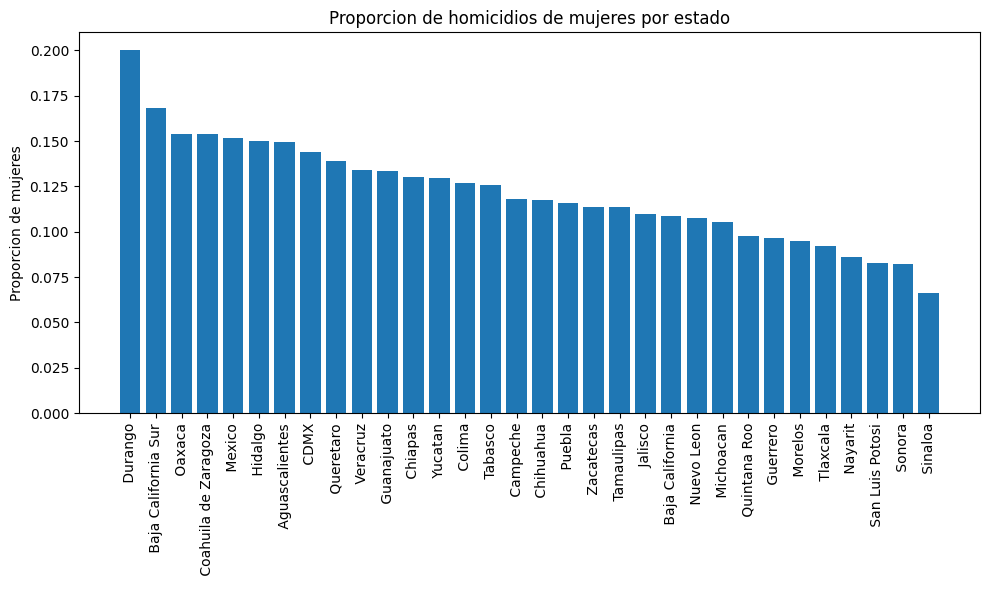

In [24]:
df_sorted = df.sort_values('Prop_Mujeres', ascending=False) #para acomodar los valores de un número alto hasta uno mas pequeño

plt.figure(figsize=(10,6)) #para colocar el tamaño de la figura
plt.bar(df_sorted.index, df_sorted['Prop_Mujeres']) #para hacer el gráfico de barras, primero para el indice en este caso estados y despues para la prop mujeres
plt.xticks(rotation=90) #para rotar los nombres de los estados
plt.ylabel('Proporcion de mujeres') #para llamar el eje y como proporcion de mujeres
plt.title('Proporcion de homicidios de mujeres por estado') #para poner titulo al gráfico
plt.tight_layout() #para acomodarlo bien
plt.show() #para mostrar la gráfica

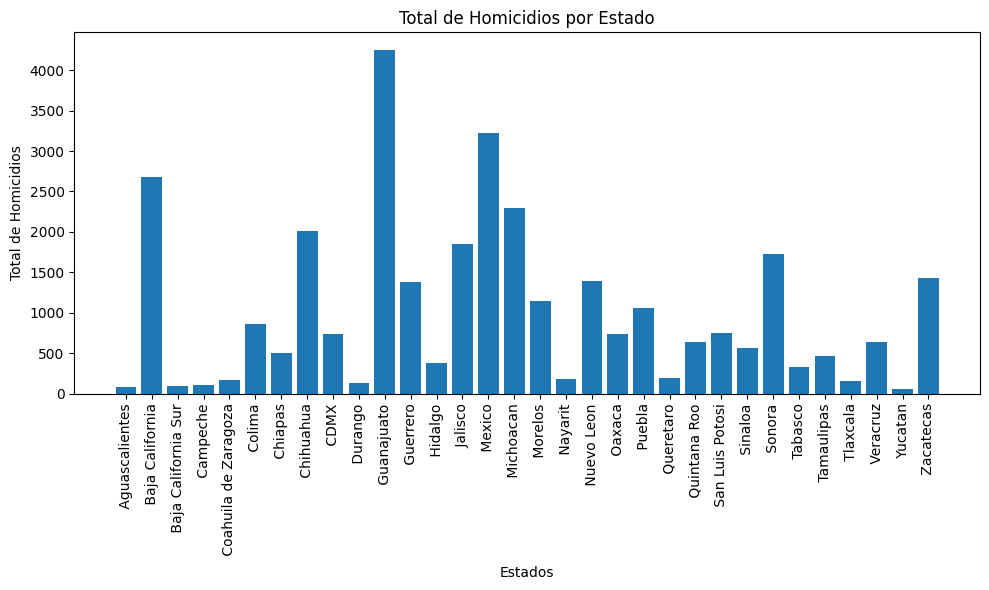

In [31]:
#Gráfica para homicidios totales
plt.figure(figsize=(10,6))

plt.bar(df.index, df['Total'], )

plt.xticks(rotation=90)
plt.xlabel('Estados')
plt.ylabel('Total de Homicidios')
plt.title('Total de Homicidios por Estado')
plt.tight_layout()
plt.show()


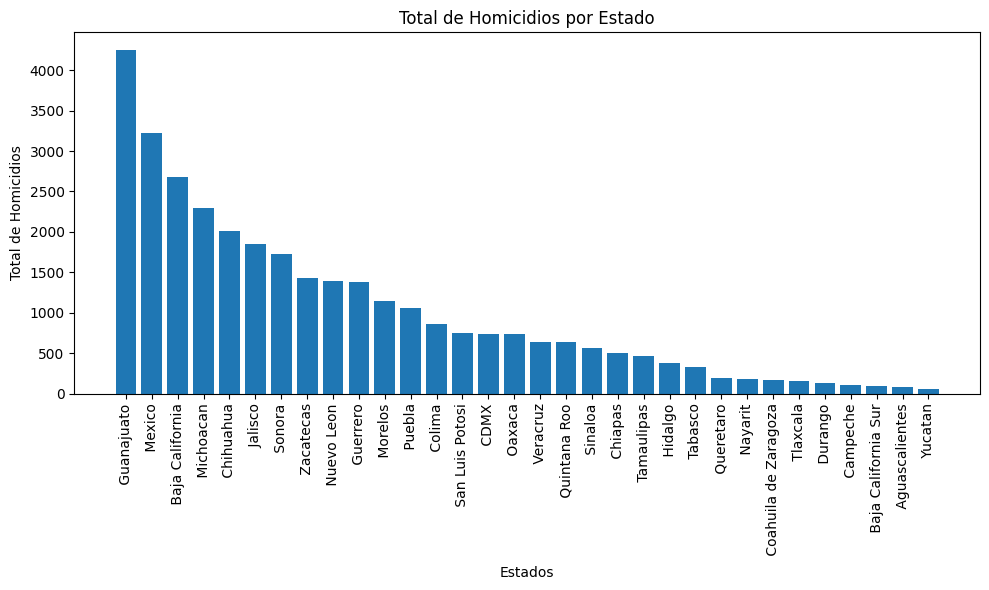

In [32]:
df_sorted = df.sort_values('Total', ascending=False) #para acomodarlo en orden

plt.figure(figsize=(10,6)) #tamaño de la gráfica

plt.bar(df_sorted.index, df_sorted['Total'], ) #para que las baras esten en orden primero los estados, despues el total

plt.xticks(rotation=90)
plt.xlabel('Estados')
plt.ylabel('Total de Homicidios')
plt.title('Total de Homicidios por Estado')
plt.tight_layout()
plt.show()


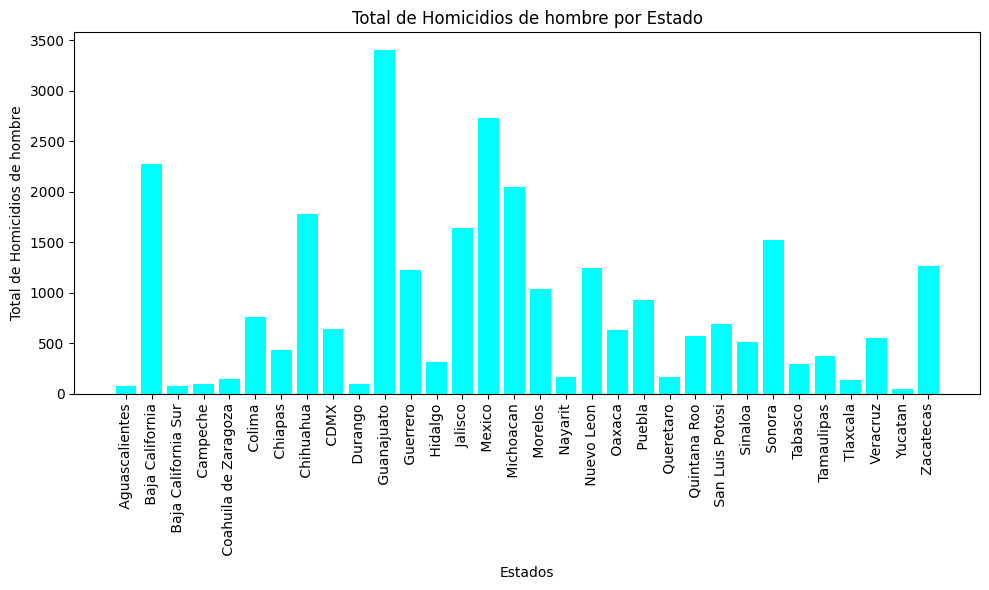

AttributeError: Figure.set() got an unexpected keyword argument 'color'

In [45]:
#para hombres
plt.figure(figsize=(10,6))

plt.bar(df.index, df['Hombres'], color = 'cyan' )

plt.xticks(rotation=90)
plt.xlabel('Estados')
plt.ylabel('Total de Homicidios de hombre')
plt.title('Total de Homicidios de hombre por Estado')
plt.tight_layout()
plt.show()

#para mujeres
plt.figure(figsize=(10,6), color = 'red')

plt.bar(df.index, df['Mujeres'], )

plt.xticks(rotation=90)
plt.xlabel('Estados')
plt.ylabel('Total de Homicidios de mujeres')
plt.title('Total de Homicidios de muejres por Estado')
plt.tight_layout()
plt.show()



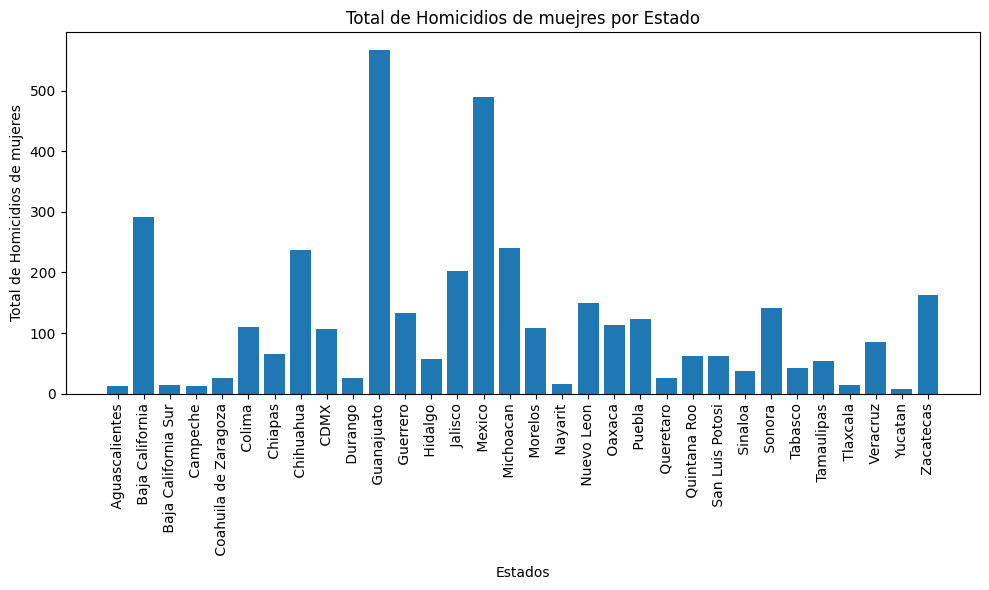

In [47]:
#para mujeres
plt.figure(figsize=(10,6),)

plt.bar(df.index, df['Mujeres'], )

plt.xticks(rotation=90)
plt.xlabel('Estados')
plt.ylabel('Total de Homicidios de mujeres')
plt.title('Total de Homicidios de muejres por Estado')
plt.tight_layout()
plt.show()


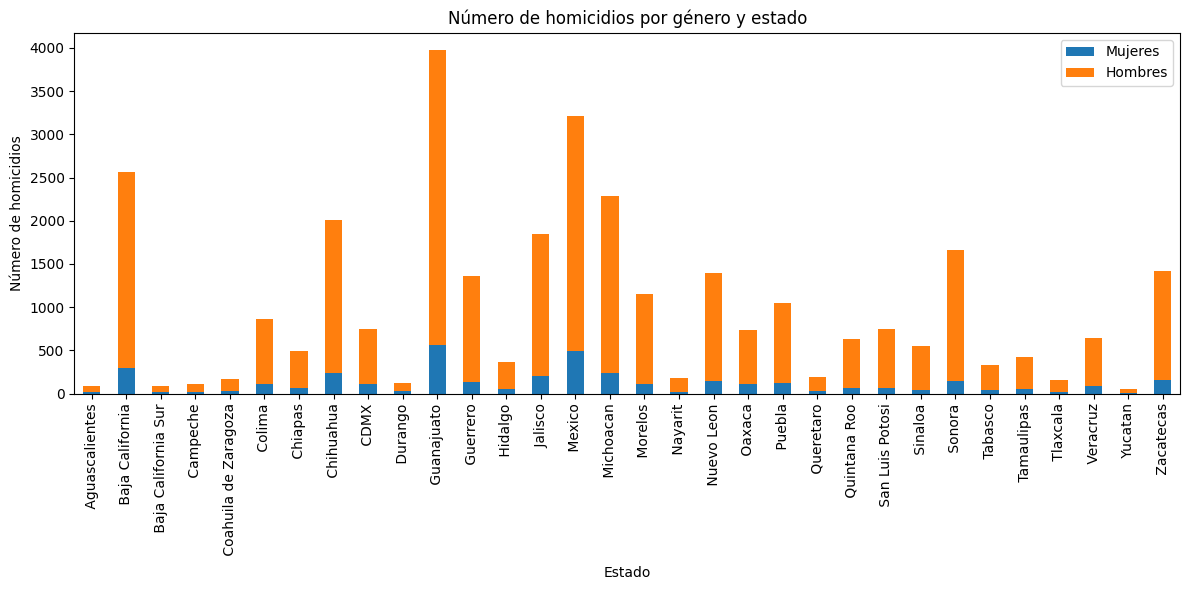

In [51]:
df[['Mujeres','Hombres']].plot(kind='bar', stacked=True,figsize=(12,6)) #llamamos el dataframe para hombres y mujeres, usamos para que sea tipo bar, que se vayan acumulando en barra, agregamos el tamaño que queramos

plt.ylabel('Número de homicidios') #damos el titulo para el eje y
plt.title('Número de homicidios por género y estado')
plt.tight_layout()
plt.show()


**TAREA**

Como acomodarlos mujeres y hombres pero de mayor a menor num de homicidios

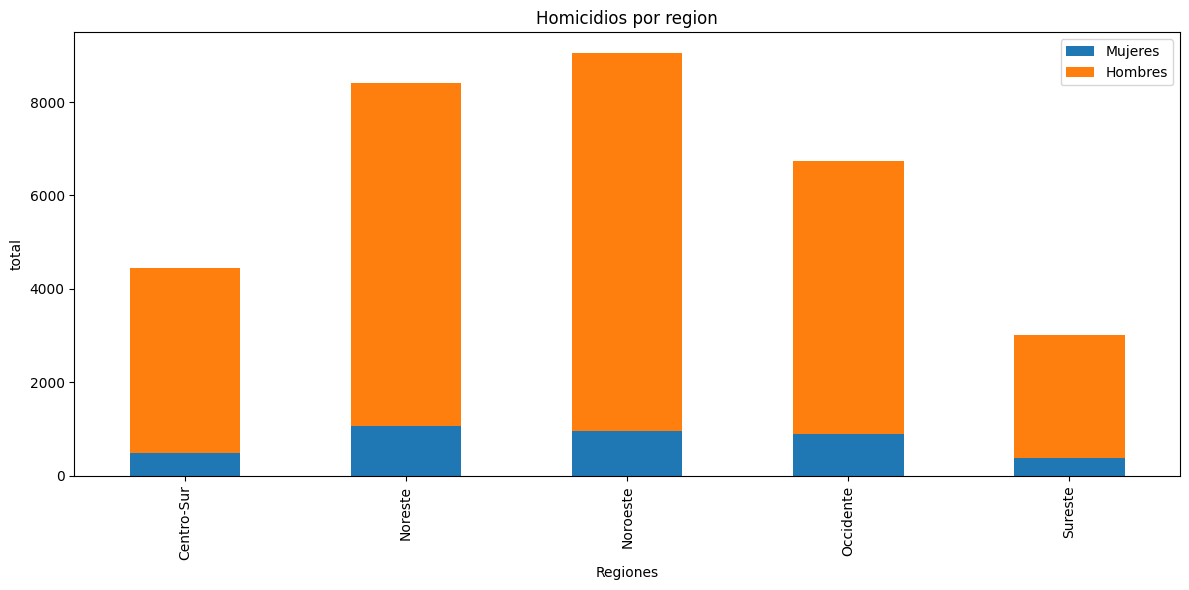

In [54]:
df_region = df.groupby('Regiones')[['Mujeres', 'Hombres']].sum()

df_region.plot (kind='bar', stacked=True,figsize=(12,6))
plt.title('Homicidios por region')
plt.ylabel('total')
plt.tight_layout()
plt.show()

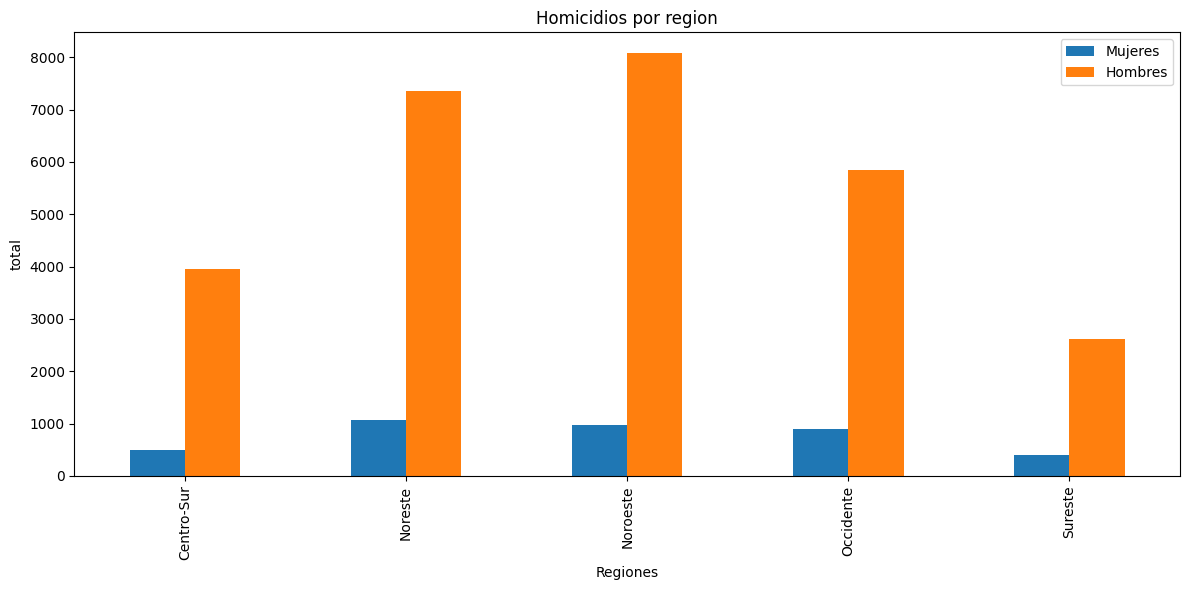

In [55]:
df_region = df.groupby('Regiones')[['Mujeres', 'Hombres']].sum()

df_region.plot (kind='bar', stacked=False,figsize=(12,6)) #con false es para que nos de dos columnas
plt.title('Homicidios por region')
plt.ylabel('total')
plt.tight_layout()
plt.show()

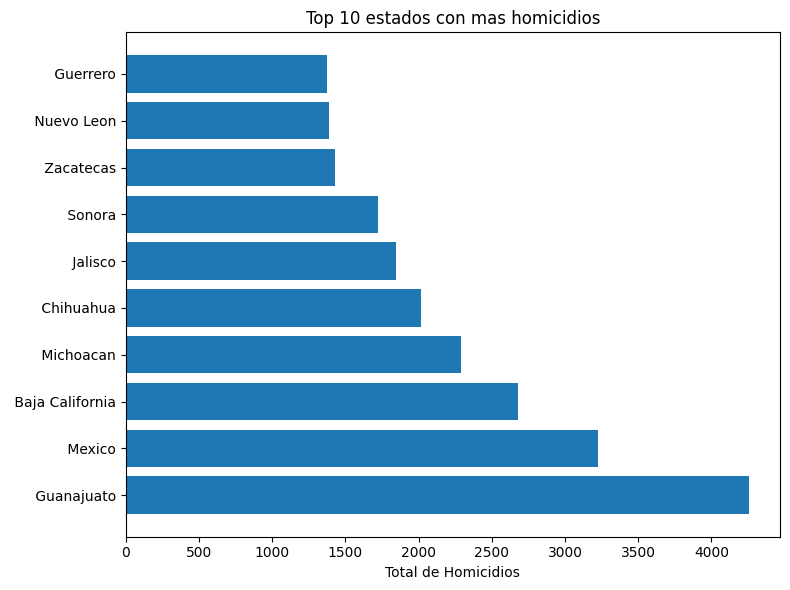

In [59]:
df_sorted = df.sort_values('Total', ascending=False).head(10) #si es false se ordenan de menor a mayor, si es true se ordenan de mayor a menor

plt.figure(figsize = (8,6))
plt.barh(df_sorted.index, df_sorted['Total'])
plt.xlabel('Total de Homicidios')
plt.title('Top 10 estados con mas homicidios')
plt.gca().invert_yaxis #para que nos de las gráficas horizontales
plt.tight_layout()
plt.show()

**INVESTIGAR COMO HACER UN GRÁFICO DE PASTEL**
